In [1]:
# imports

from MarkovChain import MarkovChain
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import plotly.express as px

### Data Processing
All of the important data processing tools can be found in data_processing.py

This code takes a list of social isolation data and converts it to a Markov Chain adjacency matrix

In [2]:
winners = MarkovChain("/Users/anu/Documents/carleton/fly_syntax_nlp/data/final_all_winners.csv")
losers = MarkovChain("/Users/anu/Documents/carleton/fly_syntax_nlp/data/final_all_losers.csv")

['abdominal', 'head', 'rubbing', 'stand', 'thorax', 'wing']


/Users/anu/Documents/carleton/fly_syntax_nlp/MarkovChain.py:65: RuntimeWarning: invalid value encountered in divide
  probabilities = (frequencies.values)/normalizing
/Users/anu/Documents/carleton/fly_syntax_nlp/MarkovChain.py:65: RuntimeWarning: invalid value encountered in divide
  probabilities = (frequencies.values)/normalizing


['abdominal', 'head', 'rubbing', 'stand', 'thorax', 'wing']


In [3]:
# embedder = TSNE(
#     n_components=3,
#     init="random",
#     max_iter=1000,
#     random_state=1,
# )

embedder = PCA(
    n_components=3
)
X = [np.reshape(df.values, 36) for df in winners.probability_list + losers.probability_list]
X_f = [np.reshape(df.values, 36) for df in winners.frequency_list + losers.frequency_list]

genotype = ["winner" for _ in winners.probability_list] + ["loser" for _ in losers.probability_list]

reduced_syntax = embedder.fit_transform(np.array(X))

In [4]:
px.scatter_3d(x=reduced_syntax[:, 0], y=reduced_syntax[:, 1], z=reduced_syntax[:, 2], color=genotype)

Text(0.5, 1.0, 'Difference')

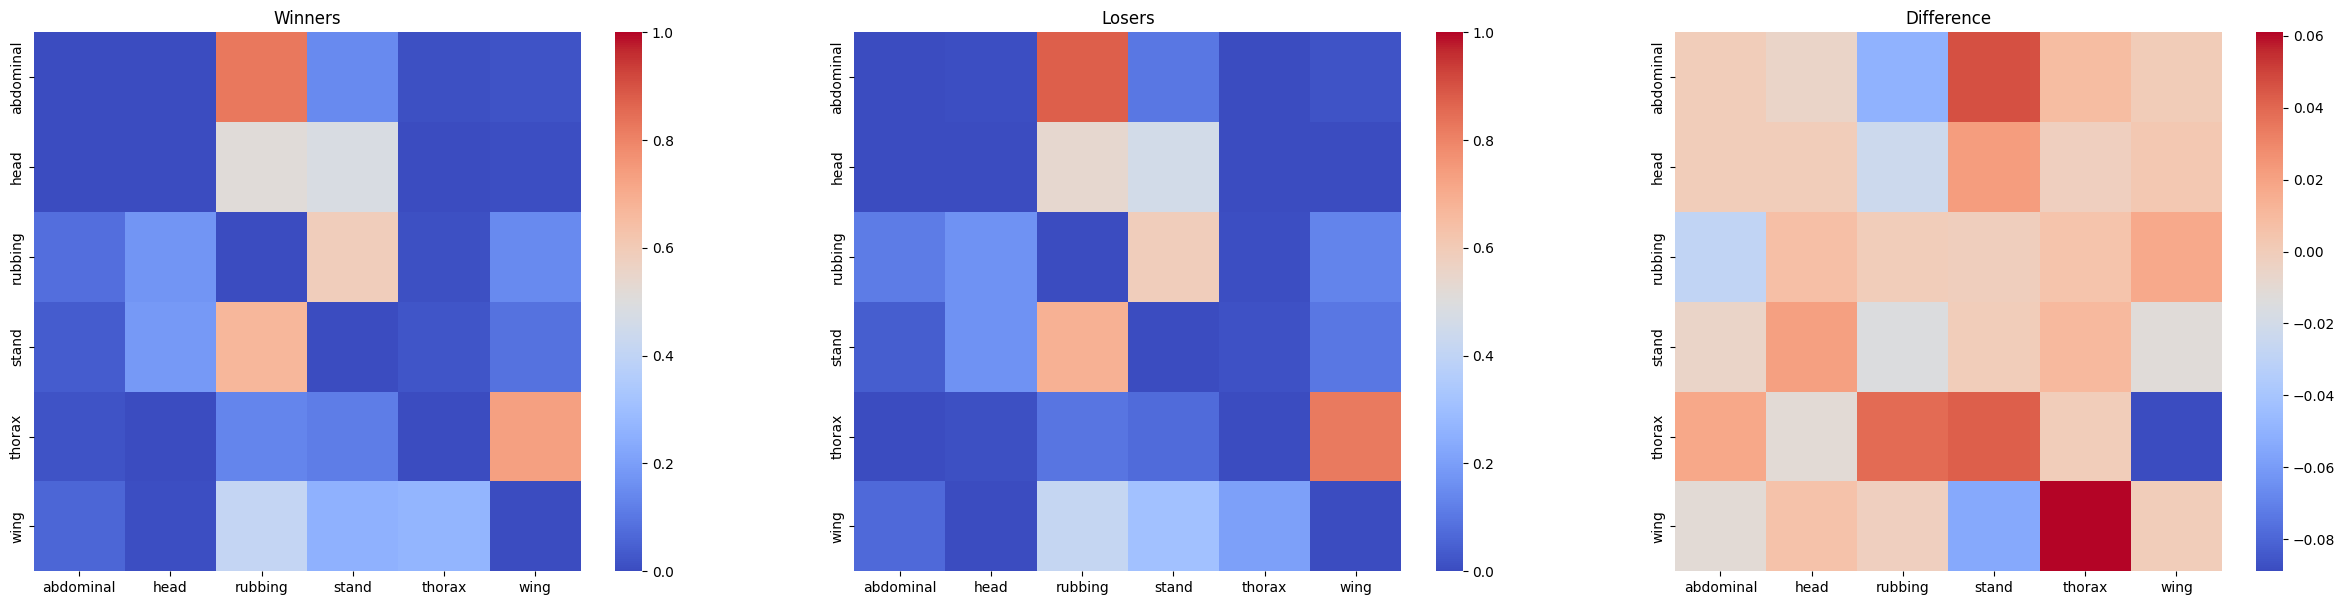

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(30, 7), sharex=True)

sns.heatmap(winners.mean_markovs_new(), ax = axes[0], vmin=0, vmax=1, cmap = "coolwarm")
axes[0].set_title('Winners')

sns.heatmap(losers.mean_markovs_new(), ax = axes[1], vmin=0, vmax=1, cmap = "coolwarm")
axes[1].set_title('Losers')

sns.heatmap(winners.mean_markovs_new() - losers.mean_markovs_new(), ax = axes[2], cmap = "coolwarm")
axes[2].set_title('Difference')

In [7]:
winners_list, winners_mu, winners_std = winners.get_entropy()
losers_list, losers_mu, losers_std = losers.get_entropy()

<Axes: ylabel='Density'>

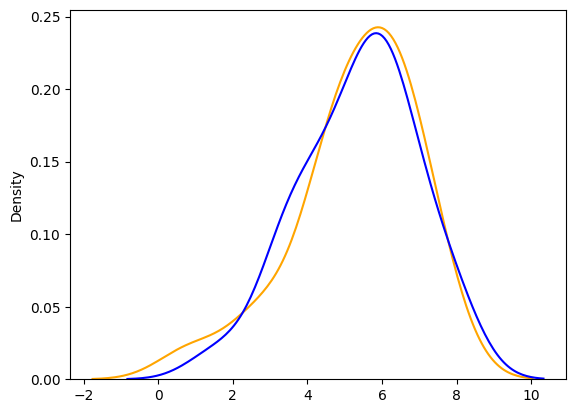

In [8]:
sns.kdeplot(winners_list, color="orange")
sns.kdeplot(losers_list, color="blue")